# 03. Análise Exploratória de Rotas Comerciais, Sazonalidade e Outliers

### Documentação da Etapa
* **Objetivo da etapa:** Diagnosticar as rotas críticas (País × SH4), analisar o comportamento sazonal do volume físico (kg) e identificar anomalias volumétricas via regra do IQR nas rotas líderes.
* **Dados de entrada:** `data/processed/df_transacional.csv`, `data/processed/df_dimensao_sh4.csv`, `data/processed/df_sazonal.csv`.
* **Procedimentos realizados:**
  1. Agregação do volume por rota (País × Produto) e cálculo de participação acumulada (Pareto).
  2. Exportação das bases de dados filtradas especificamente para as rotas Top 1 (`df_transacional_lideres.csv` e `df_sazonal_lideres.csv`).
  3. Visualização gráfica da sazonalidade intra-anual mensal agregada.
  4. Detecção de meses atípicos (outliers) sobre as séries contínuas das rotas líderes com teto IQR ($Q_3 + 1.5 \times \text{IQR}$).

In [1]:
library(readr)
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)
library(scales)
library(fs)

# Determina dinamicamente a raiz do projeto
caminho_atual <- getwd()
raiz_projeto <- ifelse(basename(caminho_atual) == "notebooks", path_dir(caminho_atual), caminho_atual)

# Carrega módulos de EDA
source(path(raiz_projeto, "R", "eda.R"))

options(scipen = 999, digits = 3)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




### 1. Carga dos Dados Processados

In [2]:
df_transacional <- read_csv2(path(raiz_projeto, "data", "processed", "df_transacional.csv"), show_col_types = FALSE)
df_dimensao_sh4 <- read_csv2(path(raiz_projeto, "data", "processed", "df_dimensao_sh4.csv"), show_col_types = FALSE)
df_sazonal <- read_csv2(path(raiz_projeto, "data", "processed", "df_sazonal.csv"), show_col_types = FALSE)

cat("Tabelas dimensionais carregadas com sucesso.\n")

ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.

ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.

ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.



Tabelas dimensionais carregadas com sucesso.


### 2. Top 3 Rotas Comerciais e Curva de Concentração (Pareto)

In [3]:
# Gera as Top 3 rotas e salva o ranking
top_rotas <- gerar_top_rotas(
  df_transacional, df_dimensao_sh4, top_n = 3,
  caminho_exportacao_csv = path(raiz_projeto, "data", "processed", "df_top_rotas.csv")
)

# Exporta também as bases transacionais e sazonais isoladas das rotas líderes (Top 1)
bases_lideres <- exportar_rotas_lideres_csv(
  df_transacional, top_rotas,
  pasta_saida = path(raiz_projeto, "data", "processed")
)

# Exibição da tabela de Pareto
top_rotas |>
  mutate(
    `Volume (Kg)` = format(volume_total_kg, big.mark = ".", decimal.mark = ",", scientific = FALSE),
    `Part. (%)` = paste0(round(participacao_pct, 2), "%"),
    `Acumulado (%)` = paste0(round(participacao_acumulada_pct, 2), "%")
  ) |>
  select(Fluxo, Município, Ranking = ranking, País, `Código SH4`, `Descrição SH4`, `Volume (Kg)`, `Part. (%)`, `Acumulado (%)`) |>
  as.data.frame()

Tabela de Top Rotas salva em: /workspaces/comex-aprendizado-estatistico_R/data/processed/df_top_rotas.csv



Fluxo,Município,Ranking,País,Código SH4,Descrição SH4,Volume (Kg),Part. (%),Acumulado (%)
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Exportação,Cubatão - SP,1,China,1201,"Soja, mesmo triturada",3.600.314.763,29.81%,29.81%
Exportação,Cubatão - SP,2,Canadá,2713,"Coque de petróleo, betume de petróleo e outros resíduos dos óleos de petróleo ou de minerais betuminosos",547.311.693,4.53%,34.35%
Exportação,Cubatão - SP,3,África do Sul,2713,"Coque de petróleo, betume de petróleo e outros resíduos dos óleos de petróleo ou de minerais betuminosos",545.342.842,4.52%,38.86%
Exportação,Guarujá - SP,1,China,1201,"Soja, mesmo triturada",10.100.727.173,78.08%,78.08%
Exportação,Guarujá - SP,2,China,1005,Milho,257.344.360,1.99%,80.07%
Exportação,Guarujá - SP,3,Japão,1201,"Soja, mesmo triturada",228.549.365,1.77%,81.83%
Exportação,Santos - SP,1,China,1201,"Soja, mesmo triturada",16.884.338.941,23.07%,23.07%
Exportação,Santos - SP,2,Singapura,2710,"Óleos de petróleo ou de minerais betuminosos, exceto óleos brutos; preparações não especificadas nem compreendidas noutras posições, contendo, em peso, 70 % ou mais de óleos de petróleo ou de minerais betuminosos, os quais devem constituir o seu elemento",6.062.891.069,8.28%,31.35%
Exportação,Santos - SP,3,Libéria,2710,"Óleos de petróleo ou de minerais betuminosos, exceto óleos brutos; preparações não especificadas nem compreendidas noutras posições, contendo, em peso, 70 % ou mais de óleos de petróleo ou de minerais betuminosos, os quais devem constituir o seu elemento",2.664.208.688,3.64%,34.99%


### 3. Sazonalidade Mensal do Volume Físico (2019–2026)

Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


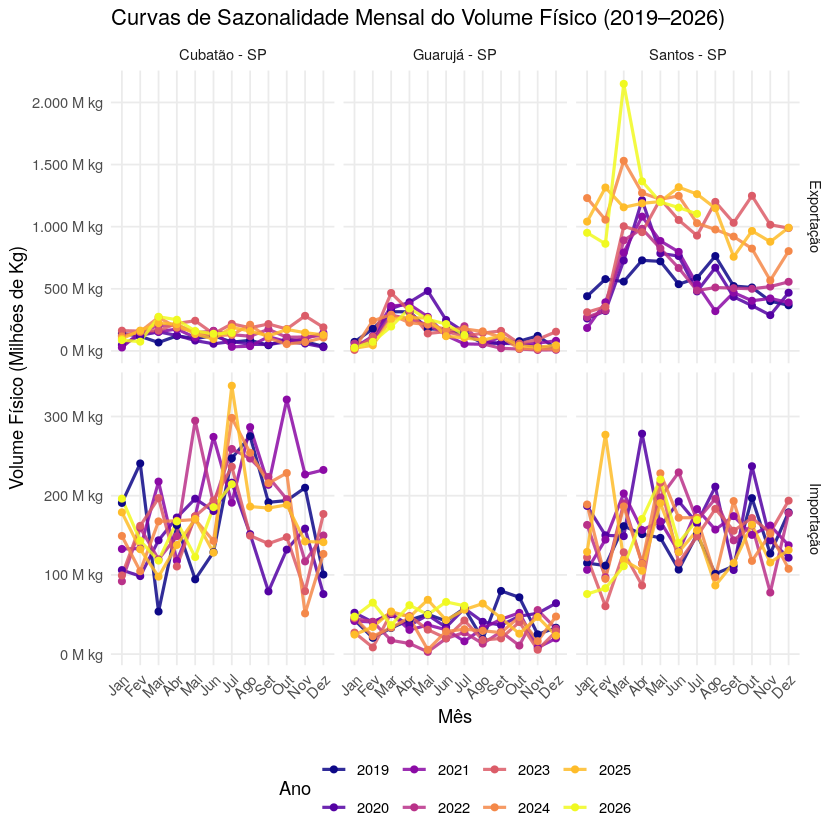

In [4]:
plotar_sazonalidade_volume(df_sazonal)

### 4. Detecção de Outliers nas Rotas Líderes (Regra do IQR)

In [5]:
# Executa o cálculo com grid contínuo e preenchimento com zero
resultado_iqr <- detectar_outliers_rotas_iqr(df_transacional, top_rotas, fator_iqr = 1.5)

cat(">>> RESUMO DOS LIMITES IQR (EM TONELADAS):\n")
print(as.data.frame(resultado_iqr$resumo_iqr), row.names = FALSE)

cat("\n>>> MESES DETECTADOS COM PICOS ATÍPICOS (OUTLIERS):\n")
print(as.data.frame(resultado_iqr$meses_outliers), row.names = FALSE)

>>> RESUMO DOS LIMITES IQR (EM TONELADAS):
    Município      Fluxo           País Código SH4
 Cubatão - SP Exportação          China       1201
 Guarujá - SP Exportação          China       1201
  Santos - SP Exportação          China       1201
 Cubatão - SP Importação          Chile       2501
 Guarujá - SP Importação Estados Unidos       2815
  Santos - SP Importação      Argentina       1001
                                                                                                                                 Descrição SH4
                                                                                                                         Soja, mesmo triturada
                                                                                                                         Soja, mesmo triturada
                                                                                                                         Soja, mesmo triturada
 Sal (incluídos o sal de mes

Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


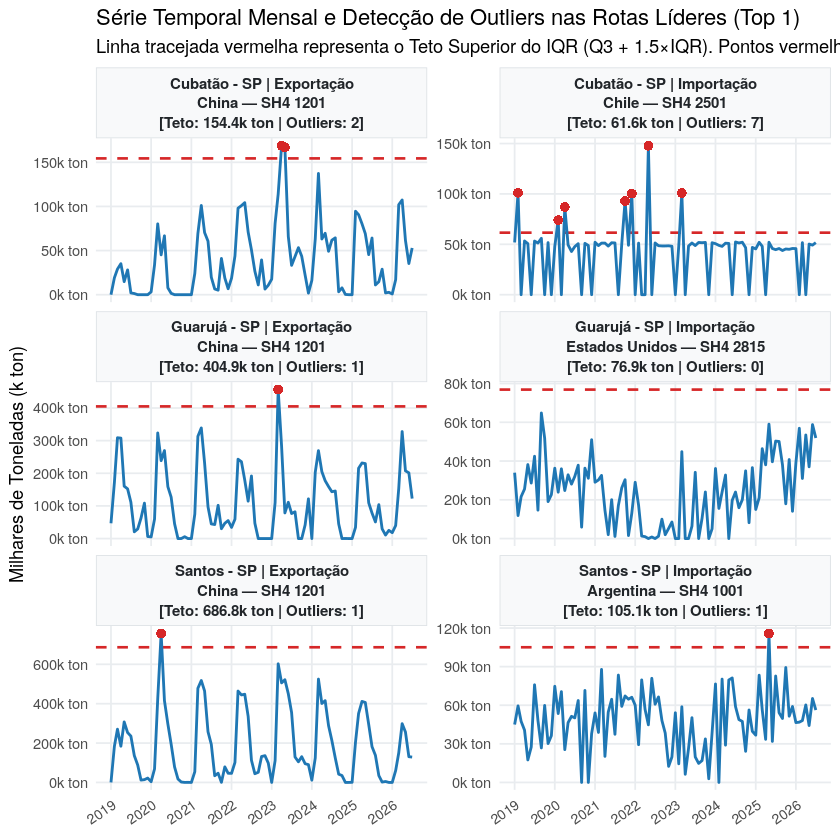

In [6]:
# Visualização gráfica das séries com destaque dos tetos e outliers
plotar_series_rotas_com_outliers(df_transacional, resultado_iqr)